[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Sharpe: 0.5835518524554579
Max Drawdown: -0.1747558883817914


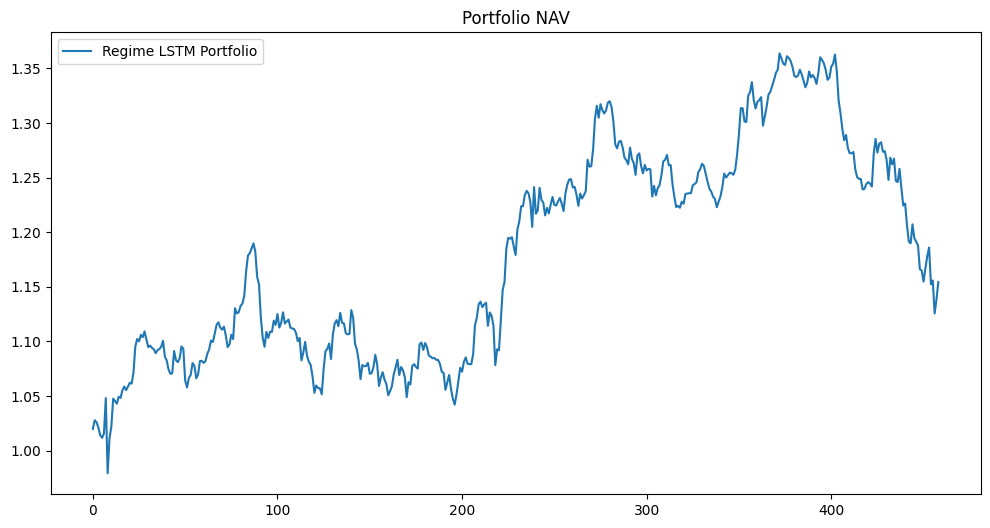

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

# ─────────────────────────────────────────
# 1. DATA DOWNLOAD
# ─────────────────────────────────────────
comp1="HDFCBANK.NS"
comp2="RELIANCE.NS"
comp3="BHARTIARTL.NS"

df_c1=yf.download(comp1,period="10y",auto_adjust=True)
df_c2=yf.download(comp2,period="10y",auto_adjust=True)
df_c3=yf.download(comp3,period="10y",auto_adjust=True)

df_c1['pct_change'] = df_c1['Close'].pct_change()
df_c2['pct_change'] = df_c2['Close'].pct_change()
df_c3['pct_change'] = df_c3['Close'].pct_change()

df_c1.drop(["High","Low","Open","Volume"],inplace=True,axis=1)
df_c2.drop(["High","Low","Open","Volume"],inplace=True,axis=1)
df_c3.drop(["High","Low","Open","Volume"],inplace=True,axis=1)

pct_chg_port=pd.concat([df_c1["pct_change"],df_c2["pct_change"],df_c3["pct_change"]],axis=1)
pct_chg_port.columns=["hdfc","reliance","airtel"]
pct_chg_port.dropna(inplace=True)

# ─────────────────────────────────────────
# 2. PORTFOLIO NAV (baseline)
# ─────────────────────────────────────────
weights_of_investment=[0.2,0.2,0.6]
daily_ret_port=pct_chg_port.dot(weights_of_investment)

initial_investment = 100
nav = initial_investment * (1 + daily_ret_port).cumprod()

df = pd.concat([pct_chg_port, nav], axis=1)
df.columns = ["hdfc","reliance","airtel","nav"]

df["log_ret"]=np.log(df["nav"]).diff()

# ─────────────────────────────────────────
# 3. FEATURES
# ─────────────────────────────────────────
df["ma_10"] = df["log_ret"].rolling(window=10).mean()
df["ma_20"] = df["log_ret"].rolling(window=20).mean()

df["ema_10"] = df["log_ret"].ewm(span=10, adjust=False).mean()
df["ema_20"] = df["log_ret"].ewm(span=20, adjust=False).mean()

df["volatility_20"] = df["log_ret"].rolling(window=20).std()

# ─────────────────────────────────────────
# 4. TARGET (MULTI-ASSET FUTURE RETURNS)
# ─────────────────────────────────────────
target = pct_chg_port.shift(-5)   # 5-day forward returns
df = df.iloc[:-5]
target = target.iloc[:-5]

# ─────────────────────────────────────────
# 5. HMM REGIME
# ─────────────────────────────────────────
from hmmlearn.hmm import GaussianHMM

hmm_data = df["log_ret"].dropna().values.reshape(-1,1)

hmm = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000)
hmm.fit(hmm_data)

hidden_states = hmm.predict(hmm_data)
state_probs = hmm.predict_proba(hmm_data)

df = df.iloc[-len(hidden_states):].copy()
target = target.iloc[-len(hidden_states):].copy()

df["state"] = hidden_states
df["prob_0"] = state_probs[:,0]
df["prob_1"] = state_probs[:,1]

# ─────────────────────────────────────────
# 6. PREPARE DATA
# ─────────────────────────────────────────
df.dropna(inplace=True)

y = target.loc[df.index]
x = df.drop(["nav"], axis=1)

split = int(len(x) * 0.8)

X_train = x.iloc[:split]
X_test  = x.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# ─────────────────────────────────────────
# 7. SCALING
# ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

# ─────────────────────────────────────────
# 8. SEQUENCE CREATION
# ─────────────────────────────────────────
def create_sequences_with_prob(X, y, probs, time_steps=30):
    Xs, ys, ps = [], [], []
    
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y.iloc[i+time_steps].values)
        ps.append(probs[i+time_steps])
        
    return np.array(Xs), np.array(ys), np.array(ps)

time_steps = 30
prob_cols = ["prob_0","prob_1"]

X_train_lstm, y_train_lstm, prob_train = create_sequences_with_prob(
    X_train_scaled, y_train, df.iloc[:split][prob_cols].values, time_steps
)

X_test_lstm, y_test_lstm, prob_test = create_sequences_with_prob(
    X_test_scaled, y_test, df.iloc[split:][prob_cols].values, time_steps
)

# ─────────────────────────────────────────
# 9. TORCH SETUP
# ─────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─────────────────────────────────────────
# 10. MODEL
# ─────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(LSTMModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 3)  # 3 assets

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

# ─────────────────────────────────────────
# 11. REGIME-SPECIFIC MODELS
# ─────────────────────────────────────────
models = {}

for state in [0,1]:
    
    idx = (df.iloc[:split]["state"].values[time_steps:] == state)
    
    if np.sum(idx) < 50:
        continue
    
    X_state = X_train_lstm[idx]
    y_state = y_train_lstm[idx]
    
    X_tensor = torch.tensor(X_state, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_state, dtype=torch.float32).to(device)
    
    model_s = LSTMModel(input_size=X_state.shape[2]).to(device)
    optimizer_s = torch.optim.Adam(model_s.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()
    
    for epoch in range(15):
        model_s.train()
        
        optimizer_s.zero_grad()
        out = model_s(X_tensor)
        loss = loss_fn(out, y_tensor)
        loss.backward()
        optimizer_s.step()
    
    models[state] = model_s

# ─────────────────────────────────────────
# 12. PREDICTION (SOFT REGIME BLENDING)
# ─────────────────────────────────────────
predictions = []

with torch.no_grad():
    
    for i in range(len(X_test_lstm)):
        
        x_input = torch.tensor(X_test_lstm[i:i+1], dtype=torch.float32).to(device)
        probs = prob_test[i]
        
        preds_all_states = []
        
        for s in models:
            pred_s = models[s](x_input).cpu().numpy()[0]
            preds_all_states.append(pred_s)
        
        preds_all_states = np.array(preds_all_states)   # (num_states, 3)
        
        final_pred = np.sum(
            probs[:len(models)].reshape(-1,1) * preds_all_states,
            axis=0
        )
        
        predictions.append(final_pred)

# ─────────────────────────────────────────
# 13. CONVERT → WEIGHTS
# ─────────────────────────────────────────
def softmax(x):
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

weights = softmax(predictions)

# ─────────────────────────────────────────
# 14. PORTFOLIO RETURNS
# ─────────────────────────────────────────
actual_returns = y_test_lstm

portfolio_returns = np.sum(weights * actual_returns, axis=1)

# ─────────────────────────────────────────
# 15. TRANSACTION COST
# ─────────────────────────────────────────


# ─────────────────────────────────────────
# 16. NAV + METRICS
# ─────────────────────────────────────────
nav = np.cumprod(1 + portfolio_returns)

sharpe = np.mean(portfolio_returns) / np.std(portfolio_returns) * np.sqrt(252)

peak = np.maximum.accumulate(nav)
drawdown = (nav - peak) / peak
max_dd = np.min(drawdown)

print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)

# ─────────────────────────────────────────
# 17. PLOT
# ─────────────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(nav, label="Regime LSTM Portfolio")
plt.legend()
plt.title("Portfolio NAV")
plt.show()